In [16]:
# baixa o repositório na máquina do colab, pra permitir o import de
# módulos do repositório
!rm -fr /content/deep-learning-pa1
!git clone https://github.com/nicolasspaniol/deep-learning-pa1.git

# adiciona o caminho do repositório clonado no path
import sys
sys.path.insert(0,'/content/deep-learning-pa1')

Cloning into 'deep-learning-pa1'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 76 (delta 24), reused 32 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (76/76), 2.89 MiB | 18.04 MiB/s, done.
Resolving deltas: 100% (24/24), done.


In [17]:
# local files
from src import utils
from src.synthetic_dataset import SyntheticEllipseDataset
from src.resunet import ResUNet

import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [19]:
# Carregando os dados: BBBC038
# Verifica se a pasta já não existe antes de baixar
if not os.path.exists('./data/stage1_train'):
    !wget https://data.broadinstitute.org/bbbc/BBBC038/stage1_train.zip -P ./data
    !cd data && unzip -q stage1_train.zip -d stage1_train

In [20]:
import os
from pathlib import Path
import numpy as np
import torch
from skimage.io import imread
from skimage.transform import resize

IMG_SIZE = 128

class BBBC038Dataset(Dataset):
    def __init__(self):
        self.train_dir = Path("data/stage1_train")
        self.ids = os.listdir(self.train_dir)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        id = self.ids[idx]
        self.mask_dir = self.train_dir / id / "masks"
        img_path = self.train_dir / id / "images" / f"{id}.png"
        image = imread(img_path)[..., :3] / 255
        masks = [imread(self.mask_dir / f) for f in os.listdir(self.mask_dir)]
        mask = np.max(masks, axis=0) / 255

        image = resize(image, (IMG_SIZE, IMG_SIZE), preserve_range=True)
        mask = resize(mask, (IMG_SIZE, IMG_SIZE), order=0, preserve_range=True, anti_aliasing=False).astype(np.uint8)

        image = torch.from_numpy(image).permute(2, 0, 1).contiguous().float()
        mask = torch.from_numpy(mask[..., None]).permute(2, 0, 1)[0].contiguous().float()

        return image, mask

In [21]:
dataset = BBBC038Dataset()
train_dataset, val_dataset, test_dataset = random_split(dataset, [0.7, 0.15, 0.15])

In [22]:
# Treinando a ResUNet no BBBC038

model = ResUNet(3, 1).to(device)

loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

model.train()
for epoch in range(5):
    for batch, (X, y) in enumerate(loader):
        X, y = X.to(device), y.to(device)

        y_hat = model(X).squeeze(1)
        loss = loss_fn(y_hat, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 5 == 0:
            print(f'{epoch}/{batch} - loss={loss}')

0/0 - loss=0.6960243582725525
0/5 - loss=0.5977331399917603
0/10 - loss=0.5408256649971008
0/15 - loss=0.5121122598648071
0/20 - loss=0.4456431567668915
0/25 - loss=0.38278287649154663
1/0 - loss=0.3191870152950287
1/5 - loss=0.3482707738876343
1/10 - loss=0.30586642026901245
1/15 - loss=0.2708238959312439
1/20 - loss=0.27216821908950806
1/25 - loss=0.3177604675292969
2/0 - loss=0.24401652812957764
2/5 - loss=0.23621103167533875
2/10 - loss=0.2700376510620117
2/15 - loss=0.25254520773887634
2/20 - loss=0.2750362157821655
2/25 - loss=0.23977982997894287
3/0 - loss=0.1707286238670349
3/5 - loss=0.19559797644615173
3/10 - loss=0.28215301036834717
3/15 - loss=0.16129758954048157
3/20 - loss=0.16056668758392334
3/25 - loss=0.16192495822906494
4/0 - loss=0.14437037706375122
4/5 - loss=0.260540634393692
4/10 - loss=0.13751667737960815
4/15 - loss=0.13021637499332428
4/20 - loss=0.21067184209823608
4/25 - loss=0.18161994218826294


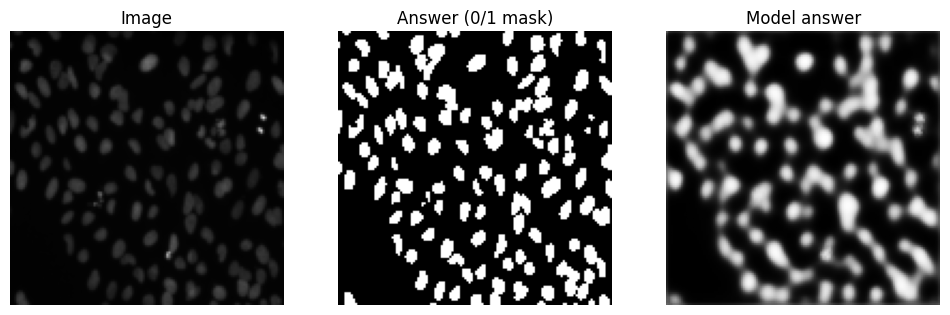

In [23]:
# Verificando a saída do modelo

model.eval()

for img, mask in DataLoader(test_dataset, shuffle=True):
    img, mask = img.to(device), mask.to(device)

    y = F.sigmoid(model(img))[0,0].cpu().detach().numpy()
    img = img[0].permute(1, 2, 0).cpu().detach().numpy()
    mask = mask[0].cpu().detach().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img)
    axes[0].set_title("Image")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Answer (0/1 mask)")
    axes[1].axis("off")

    axes[2].imshow(y, cmap="gray")
    axes[2].set_title("Model answer")
    axes[2].axis("off")


    plt.show()

    break

In [28]:
# computa o IoU e Dice no conjunto de treino

model.eval()

thresholds = torch.arange(0, 1, .05)
iou_scores, dice_scores = [], []

with torch.no_grad():
    for x, y in DataLoader(test_dataset, pin_memory=True):
        y_hat = F.sigmoid(model(x.to(device, non_blocking=True))[0]).cpu()

        iou_scores.append([utils.iou_score(1 * (y_hat > th), y) for th in thresholds])

        dice_scores.append([utils.dice_score(1 * (y_hat > th), y) for th in thresholds])

iou_scores = torch.tensor(iou_scores, dtype=torch.float32).mean(dim=0)
dice_scores = torch.tensor(dice_scores, dtype=torch.float32).mean(dim=0)




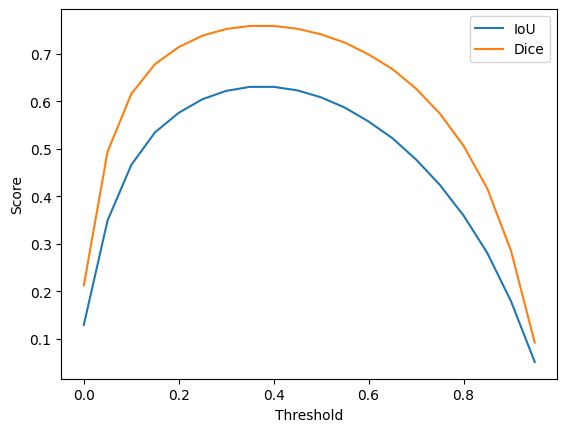

In [29]:
plt.plot(thresholds, iou_scores, label='IoU')
plt.plot(thresholds, dice_scores, label='Dice')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.show()

In [30]:
def probability_to_instances(probability, threshold=0.5):

    binary_mask = (probability >= threshold).astype(np.uint8)

    number_of_labels, instance_map = cv2.connectedComponents(
        binary_mask,
        connectivity=8
    )

    return instance_map.astype(np.int32)

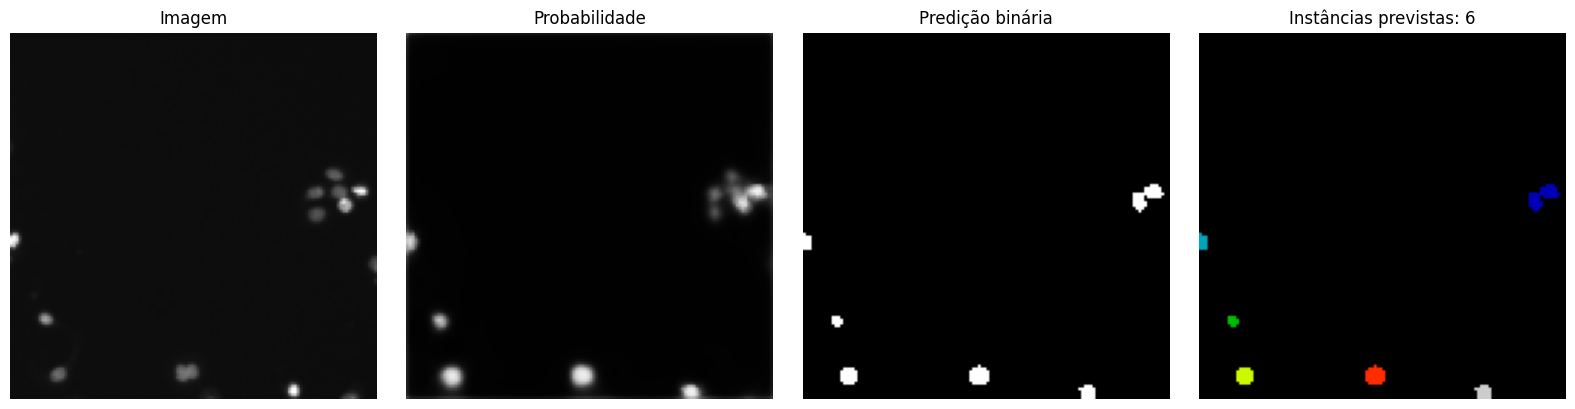

In [37]:
model.eval()

with torch.no_grad():
    for img, mask in DataLoader(test_dataset, shuffle=True):
        img_device = img.to(device)

        probability = torch.sigmoid(
            model(img_device)
        )[0, 0].cpu().numpy()

        pred_instance_map = probability_to_instances(
            probability,
            threshold=0.5
        )

        binary_prediction = probability >= 0.5
        n_pred = pred_instance_map.max()

        image = img[0].permute(1, 2, 0).numpy()
        ground_truth = mask[0].numpy()

        fig, axes = plt.subplots(1, 4, figsize=(16, 4))

        axes[0].imshow(image)
        axes[0].set_title("Imagem")

        axes[1].imshow(probability, cmap="gray", vmin=0, vmax=1)
        axes[1].set_title("Probabilidade")

        axes[2].imshow(binary_prediction, cmap="gray")
        axes[2].set_title("Predição binária")

        axes[3].imshow(pred_instance_map, cmap="nipy_spectral")
        axes[3].set_title(f"Instâncias previstas: {n_pred}")

        for ax in axes:
            ax.axis("off")

        plt.tight_layout()
        plt.show()

        break

In [ ]:
class InstanceEvaluationSubset(Dataset):
    def __init__(self, original_dataset, indices):
        self.original_dataset = original_dataset
        self.indices = list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, position):
        original_index = self.indices[position]

        image, semantic_mask = self.original_dataset[original_index]

        image_id = self.original_dataset.ids[original_index]
        mask_dir = (
            self.original_dataset.train_dir
            / image_id
            / "masks"
        )

        instance_map = np.zeros(
            (IMG_SIZE, IMG_SIZE)
        )



